# Component ablation: which part of DPHGNN's dual spatial/spectral design actually matters?

Reads `e2_ablation_results.json` (written by `run_e2.py`) and produces the two figures described in `README.md`. **This notebook only reads results and plots -- it never trains a model.** Re-running it top to bottom should take seconds.

See `README.md` in this folder for the scientific question (H1, H2, H3), the six ablation arms, the experimental design, and the finding.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_HERE = Path.cwd().resolve()
_IS_ANALYSIS_DIR = (
    (_HERE / "e2_ablation_results.json").exists()
    or (_HERE / "run_e2.py").exists()
)
_ANALYSIS_DIR = _HERE if _IS_ANALYSIS_DIR else _HERE.parent
_CHALLENGE_DIR = _ANALYSIS_DIR.parent.parent
for _p in (_CHALLENGE_DIR,):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

# Import the challenge `utils.py` (not `topobench.utils`) *before* any
# `topobench` import -- see the note in `run_e2.py` for why.
from utils import apply_publication_matplotlib_style

RESULTS_PATH = _ANALYSIS_DIR / "e2_ablation_results.json"
E1_RESULTS_PATH = (
    _ANALYSIS_DIR.parent / "lifting_confounding_study" / "lifting_ablation_results.json"
)
FIGURES_DIR = _ANALYSIS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

apply_publication_matplotlib_style()


In [2]:
if RESULTS_PATH.exists():
    with RESULTS_PATH.open(encoding="utf-8") as f:
        all_records = json.load(f)
else:
    all_records = []

ok_records = [r for r in all_records if r.get("status") == "ok"]
failed_records = [r for r in all_records if r.get("status") != "ok"]

print(f"{len(all_records)} total record(s): {len(ok_records)} ok, {len(failed_records)} failed.")
if failed_records:
    print("Failed runs:")
    for r in failed_records:
        print(f"  - {r.get('arm')}/{r.get('cell_key')}/s{r.get('seed')}: {r.get('error')}")
if not all_records:
    print(
        "\nNo records yet -- run_e2.py has not been run (Phase 1 is reserved "
        "for a Kaggle GPU session, see kaggle_run_ablation.ipynb). The cells below "
        "are written to degrade gracefully: they will report 'no data' "
        "instead of plotting until e2_ablation_results.json is populated."
    )


36 total record(s): 36 ok, 0 failed.


## Design constants

Two official cells contrasted on homophily (`avg_degree` held at `d_lo`, `power_law` at `pl_lo` throughout, see `README.md`), and six ablation arms (`A0` full reference, `A1`-`A5` per-component ablations).

In [3]:
CELL_ORDER = [
    "h_lo__d_lo__pl_lo",
    "h_hi__d_lo__pl_lo",
]
CELL_LABELS = {
    "h_lo__d_lo__pl_lo": "h_lo (severe heterophily)",
    "h_hi__d_lo__pl_lo": "h_hi (strong homophily)",
}

ARM_ORDER = ["A0", "A1", "A2", "A3", "A4", "A5"]
ARM_LABELS = {
    "A0": "A0 full",
    "A1": "A1 spatial_only",
    "A2": "A2 spectral_only",
    "A3": "A3 fusion_sum",
    "A4": "A4 no_sib",
    "A5": "A5 clique_only",
}
ARM_COLORS = {
    "A1": "#1b9e77",
    "A2": "#d95f02",
    "A3": "#7570b3",
    "A4": "#e7298a",
    "A5": "#66a61e",
}
CELL_COLORS = {
    "h_lo__d_lo__pl_lo": "#1f77b4",
    "h_hi__d_lo__pl_lo": "#d62728",
}

seeds_present = sorted({int(r["seed"]) for r in ok_records})
n_seeds = len(seeds_present)
print(f"Seeds present: {seeds_present}")

if 0 < n_seeds <= 1:
    print(
        "\n*** Phase 1 uses a single seed; differences under ~2 "
        "accuracy points are not interpretable. ***"
    )


Seeds present: [42, 43, 44]


In [4]:
def mean_accuracy(arm, cell_key):
    """Return the mean test accuracy for (arm, cell_key) over available seeds, or NaN."""
    vals = [
        r["test_accuracy"]
        for r in ok_records
        if r["arm"] == arm and r["cell_key"] == cell_key
        and r["test_accuracy"] is not None
    ]
    return float(np.mean(vals)) if vals else float("nan")


def n_params_for(arm):
    """Return the (arm-invariant, by design) n_params for `arm`, or NaN."""
    vals = [
        r["n_params"]
        for r in ok_records
        if r["arm"] == arm and r["n_params"] is not None
    ]
    return float(np.mean(vals)) if vals else float("nan")


acc_table = {
    arm: [mean_accuracy(arm, cell) for cell in CELL_ORDER] for arm in ARM_ORDER
}
n_params_table = {arm: n_params_for(arm) for arm in ARM_ORDER}

print(f"{'arm':<20}" + "".join(f"{CELL_LABELS[c]:>26}" for c in CELL_ORDER) + f"{'n_params':>12}")
for arm in ARM_ORDER:
    row = "".join(
        f"{v:>26.4f}" if np.isfinite(v) else f"{'NA':>26}" for v in acc_table[arm]
    )
    np_str = f"{n_params_table[arm]:>12.0f}" if np.isfinite(n_params_table[arm]) else f"{'NA':>12}"
    print(f"{ARM_LABELS[arm]:<20}{row}{np_str}")


arm                  h_lo (severe heterophily)   h_hi (strong homophily)    n_params
A0 full                                 0.2832                    0.6142       55630
A1 spatial_only                         0.2878                    0.6134       55630
A2 spectral_only                        0.2764                    0.5886       55630
A3 fusion_sum                           0.2825                    0.6116       55630
A4 no_sib                               0.2850                    0.6144       55630
A5 clique_only                          0.2844                    0.6177       55630


## Figure 1 -- `fig3_ablation_delta.png` (main)

Horizontal bar chart of `Δ = accuracy(arm) − accuracy(A0)`, one bar per ablation arm (`A1`-`A5`), two panels side by side (left = `h_lo`, right = `h_hi`), shared x axis. A vertical line at zero marks the `A0` reference. Bars left of zero (negative Δ) mean the ablated component helped the full model (removing it hurts); bars right of zero mean it hurt. The *difference in bar magnitude between the two panels* is the evidence for H3 (regime-dependence).

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


Saved /home/gabriel/projets/topobench/2026_tdl_challenge/extra_analysis_oversmooth_operators/model_ablation/figures/fig3_ablation_delta.png


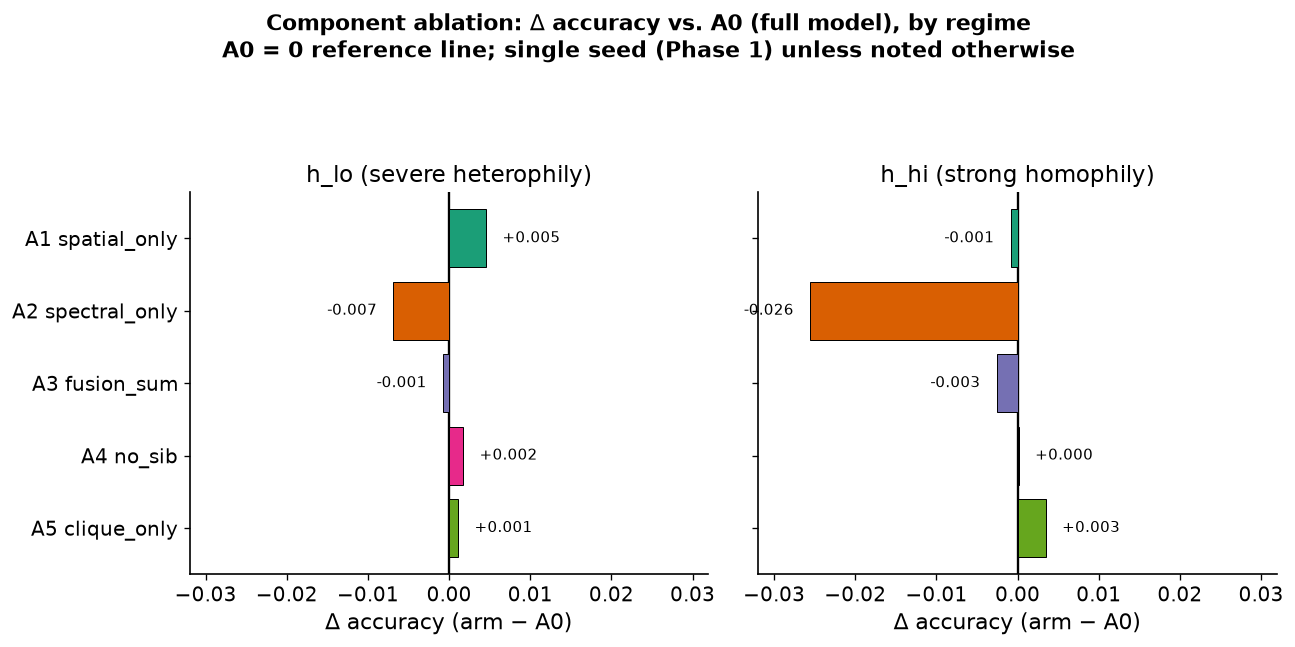

In [5]:
def plot_ablation_delta():
    if not ok_records or "A0" not in acc_table:
        print("No data yet -- skipping fig3_ablation_delta.png.")
        return None

    delta_arms = [a for a in ARM_ORDER if a != "A0"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), sharex=True)

    all_deltas = []
    for ax, cell_idx, cell in zip(axes, range(len(CELL_ORDER)), CELL_ORDER):
        a0_acc = acc_table["A0"][cell_idx]
        deltas = [acc_table[a][cell_idx] - a0_acc for a in delta_arms]
        all_deltas.extend([d for d in deltas if np.isfinite(d)])
        colors = [ARM_COLORS[a] for a in delta_arms]
        y = np.arange(len(delta_arms))
        ax.barh(y, deltas, color=colors, edgecolor="black", linewidth=0.6)
        ax.axvline(0.0, color="black", linewidth=1.4, zorder=0)
        ax.set_yticks(y)
        ax.set_yticklabels([ARM_LABELS[a] for a in delta_arms])
        ax.set_title(CELL_LABELS[cell])
        ax.set_xlabel(r"$\Delta$ accuracy (arm $-$ A0)")
        for yi, d in zip(y, deltas):
            if np.isfinite(d):
                ax.text(
                    d + (0.002 if d >= 0 else -0.002),
                    yi,
                    f"{d:+.3f}",
                    va="center",
                    ha="left" if d >= 0 else "right",
                    fontsize=9,
                )

    axes[0].invert_yaxis()
    axes[1].invert_yaxis()
    axes[1].set_yticklabels([])
    if len(all_deltas) >= 1:
        span = max(abs(min(all_deltas)), abs(max(all_deltas)), 1e-3)
        for ax in axes:
            ax.set_xlim(-1.25 * span, 1.25 * span)

    fig.suptitle(
        "Component ablation: $\Delta$ accuracy vs. A0 (full model), by regime\n"
        "A0 = 0 reference line; single seed (Phase 1) unless noted otherwise",
        fontsize=13,
        fontweight="600",
    )
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    out_path = FIGURES_DIR / "fig3_ablation_delta.png"
    fig.savefig(out_path, bbox_inches="tight")
    print(f"Saved {out_path}")
    return fig


_ = plot_ablation_delta()


## Figure 2 -- `fig4_component_by_regime.png`

Grouped bars: x = arms (`A0`-`A5`), y = raw test accuracy, one colour per cell. Dashed horizontal lines show the Experiment-E1 GCN baseline (`lifting_confounding_study/lifting_ablation_results.json`, arm `gcn`) per cell, if available -- this tells the reader whether an *ablated* DPHGNN is still above the Track-1 baseline, or whether a given component's removal drops it below GCN.

Saved /home/gabriel/projets/topobench/2026_tdl_challenge/extra_analysis_oversmooth_operators/model_ablation/figures/fig4_component_by_regime.png


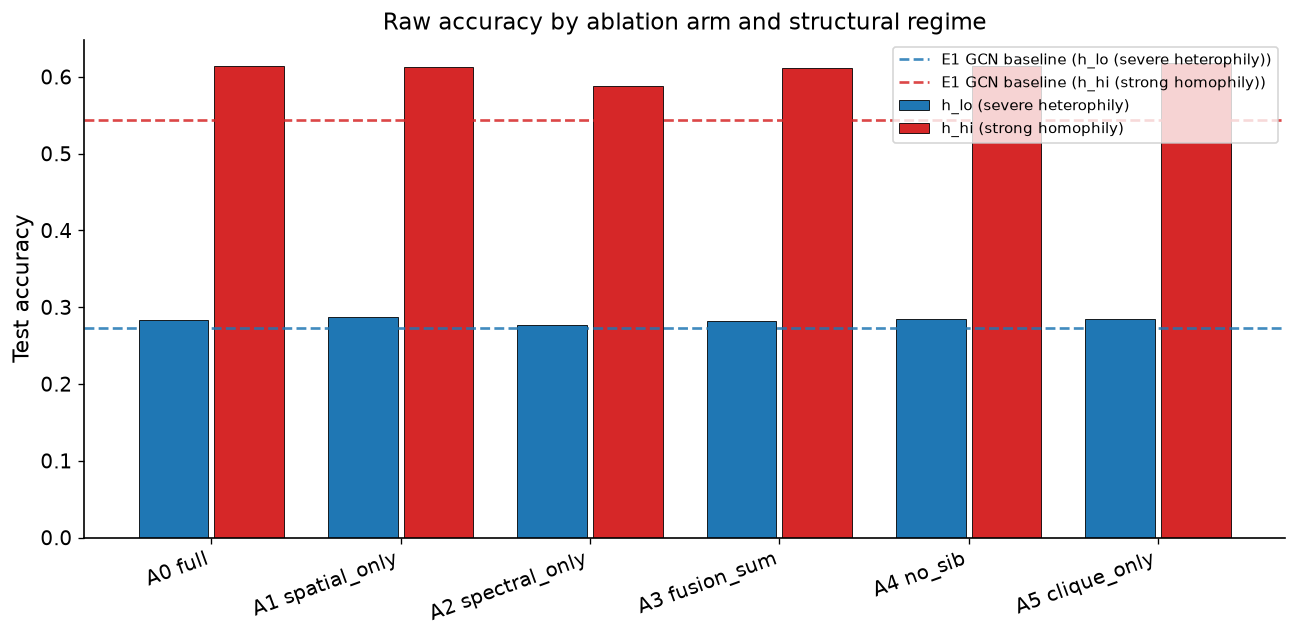

In [6]:
def load_e1_gcn_baseline():
    """Return {cell_key: mean gcn test_accuracy} from the E1 results, or {}."""
    if not E1_RESULTS_PATH.exists():
        return {}
    with E1_RESULTS_PATH.open(encoding="utf-8") as f:
        e1_records = json.load(f)
    by_cell = {}
    for cell in CELL_ORDER:
        vals = [
            r["test_accuracy"]
            for r in e1_records
            if r.get("status") == "ok"
            and r.get("arm") == "gcn"
            and r.get("cell_key") == cell
            and r.get("test_accuracy") is not None
        ]
        if vals:
            by_cell[cell] = float(np.mean(vals))
    return by_cell


def plot_component_by_regime():
    if not ok_records:
        print("No data yet -- skipping fig4_component_by_regime.png.")
        return None

    gcn_baseline = load_e1_gcn_baseline()
    fig, ax = plt.subplots(figsize=(11, 5.5))
    n_arms = len(ARM_ORDER)
    n_cells = len(CELL_ORDER)
    width = 0.8 / n_cells
    x = np.arange(n_arms)

    for i, cell in enumerate(CELL_ORDER):
        y = [acc_table[a][i] for a in ARM_ORDER]
        offset = (i - (n_cells - 1) / 2) * width
        ax.bar(
            x + offset, y, width=width * 0.92,
            color=CELL_COLORS[cell], edgecolor="black", linewidth=0.5,
            label=CELL_LABELS[cell],
        )
        if cell in gcn_baseline:
            ax.axhline(
                gcn_baseline[cell], color=CELL_COLORS[cell], linestyle="--",
                linewidth=1.6, alpha=0.85,
                label=f"E1 GCN baseline ({CELL_LABELS[cell]})",
            )

    ax.set_xticks(x)
    ax.set_xticklabels([ARM_LABELS[a] for a in ARM_ORDER], rotation=20, ha="right")
    ax.set_ylabel("Test accuracy")
    ax.set_title("Raw accuracy by ablation arm and structural regime")
    ax.legend(fontsize=9, loc="best")
    fig.tight_layout()
    out_path = FIGURES_DIR / "fig4_component_by_regime.png"
    fig.savefig(out_path, bbox_inches="tight")
    print(f"Saved {out_path}")
    return fig


_ = plot_component_by_regime()


## Statistics

**Phase 1 (n=1 seed):** no significance testing. Raw deltas only, with an explicit caveat printed below: differences under ~2 accuracy points are not interpretable at n=1.

**Phase 2 (n=3 seeds), once available:** paired comparison of each arm against `A0` *within cell*, bootstrap 95% CIs on the deltas (not ±std -- three seeds do not support an SD estimate). For H3, the quantity of interest is the **difference of deltas** across cells: `Δ_arm(h_lo) − Δ_arm(h_hi)`, reported with a bootstrap CI -- a CI excluding zero is the evidence for regime-dependence. No t-test per arm is run: with 6 arms, multiplicity correction would leave n=3 underpowered; effect sizes with CIs are reported instead.

In [7]:
def bootstrap_ci(values, n_boot=2000, ci=0.95, rng=None):
    """Return a (mean, lo, hi) percentile bootstrap CI for `values`."""
    values = np.asarray([v for v in values if np.isfinite(v)], dtype=float)
    if values.size == 0:
        return float("nan"), float("nan"), float("nan")
    rng = rng or np.random.default_rng(0)
    boots = rng.choice(values, size=(n_boot, values.size), replace=True).mean(axis=1)
    lo, hi = np.percentile(boots, [(1 - ci) / 2 * 100, (1 + ci) / 2 * 100])
    return float(values.mean()), float(lo), float(hi)


def per_seed_accuracy(arm, cell_key):
    return [
        r["test_accuracy"]
        for r in ok_records
        if r["arm"] == arm and r["cell_key"] == cell_key
        and r["test_accuracy"] is not None
    ]


if n_seeds <= 1:
    print(
        "Phase 1 only (n<=1 seed): no significance testing performed. "
        "Differences under ~2 accuracy points are not interpretable. "
        "Report raw deltas only (Figure 1 above)."
    )
elif n_seeds >= 2:
    print(f"n={n_seeds} seeds present -- computing bootstrap CIs.\n")
    rng = np.random.default_rng(0)
    print(f"{'arm':<20}{'cell':<26}{'delta mean':>12}{'95% CI':>22}")
    for arm in ARM_ORDER:
        if arm == "A0":
            continue
        for cell in CELL_ORDER:
            a0_vals = per_seed_accuracy("A0", cell)
            arm_vals = per_seed_accuracy(arm, cell)
            n = min(len(a0_vals), len(arm_vals))
            if n == 0:
                continue
            deltas = [arm_vals[i] - a0_vals[i] for i in range(n)]
            mean, lo, hi = bootstrap_ci(deltas, rng=rng)
            print(f"{ARM_LABELS[arm]:<20}{CELL_LABELS[cell]:<26}{mean:>12.4f}   [{lo:.4f}, {hi:.4f}]")

    print("\nDifference of deltas across cells (H3: regime-dependence):")
    print(f"{'arm':<20}{'diff mean':>12}{'95% CI':>22}")
    for arm in ARM_ORDER:
        if arm == "A0":
            continue
        a0_lo = per_seed_accuracy("A0", CELL_ORDER[0])
        arm_lo = per_seed_accuracy(arm, CELL_ORDER[0])
        a0_hi = per_seed_accuracy("A0", CELL_ORDER[1])
        arm_hi = per_seed_accuracy(arm, CELL_ORDER[1])
        n_lo = min(len(a0_lo), len(arm_lo))
        n_hi = min(len(a0_hi), len(arm_hi))
        if n_lo == 0 or n_hi == 0:
            continue
        deltas_lo = [arm_lo[i] - a0_lo[i] for i in range(n_lo)]
        deltas_hi = [arm_hi[i] - a0_hi[i] for i in range(n_hi)]
        # Independent-samples bootstrap on the difference of the two delta
        # distributions (deltas_lo - deltas_hi), resampled separately.
        boots_lo = rng.choice(deltas_lo, size=(2000, len(deltas_lo)), replace=True).mean(axis=1)
        boots_hi = rng.choice(deltas_hi, size=(2000, len(deltas_hi)), replace=True).mean(axis=1)
        diff_boots = boots_lo - boots_hi
        mean_diff = float(np.mean(deltas_lo) - np.mean(deltas_hi))
        lo_ci, hi_ci = np.percentile(diff_boots, [2.5, 97.5])
        print(f"{ARM_LABELS[arm]:<20}{mean_diff:>12.4f}   [{lo_ci:.4f}, {hi_ci:.4f}]")
else:
    print("No records yet -- statistics will populate once run_e2.py has produced results.")


n=3 seeds present -- computing bootstrap CIs.

arm                 cell                        delta mean                95% CI
A1 spatial_only     h_lo (severe heterophily)       0.0046   [0.0008, 0.0072]
A1 spatial_only     h_hi (strong homophily)        -0.0009   [-0.0066, 0.0028]
A2 spectral_only    h_lo (severe heterophily)      -0.0069   [-0.0155, -0.0016]
A2 spectral_only    h_hi (strong homophily)        -0.0256   [-0.0295, -0.0225]
A3 fusion_sum       h_lo (severe heterophily)      -0.0008   [-0.0019, 0.0005]
A3 fusion_sum       h_hi (strong homophily)        -0.0026   [-0.0060, 0.0039]
A4 no_sib           h_lo (severe heterophily)       0.0018   [0.0006, 0.0026]
A4 no_sib           h_hi (strong homophily)         0.0002   [-0.0015, 0.0024]
A5 clique_only      h_lo (severe heterophily)       0.0011   [-0.0004, 0.0040]
A5 clique_only      h_hi (strong homophily)         0.0035   [-0.0029, 0.0091]

Difference of deltas across cells (H3: regime-dependence):
arm                   

## Finding

Printed programmatically from whatever data is currently in `e2_ablation_results.json`, so this cell never goes stale relative to the committed JSON -- it honestly reports "not yet run" until Phase 1 completes on Kaggle (see `kaggle_run_ablation.ipynb`).

In [8]:
def print_finding():
    if not ok_records:
        print(
            "Status: NOT YET RUN. Phase 1 (12 runs: 6 arms x 2 cells x seed 42) "
            "has not been executed -- real training is reserved for a Kaggle "
            "GPU session (kaggle_run_ablation.ipynb), not this local environment. "
            "All code (ablation flags, unit tests, preflight checks, this "
            "notebook) is implemented and mechanically validated via "
            "--smoke-test --cpu, but no real accuracies exist yet to report "
            "H1/H2/H3 against."
        )
        return

    lines = []
    if "A0" in acc_table:
        deltas_by_arm = {
            a: [acc_table[a][i] - acc_table["A0"][i] for i in range(len(CELL_ORDER))]
            for a in ARM_ORDER if a != "A0"
        }
        worst_h1_arm = max(
            (a for a in ("A1", "A2", "A4") if a in deltas_by_arm),
            key=lambda a: max(abs(d) for d in deltas_by_arm[a]),
            default=None,
        )
        if worst_h1_arm is not None:
            biggest = max(deltas_by_arm[worst_h1_arm], key=abs)
            lines.append(
                f"1. H1: the largest single-branch effect is {ARM_LABELS[worst_h1_arm]} "
                f"({biggest:+.3f} accuracy vs A0 in its most-affected cell)."
            )
        if "A3" in deltas_by_arm:
            a3 = deltas_by_arm["A3"]
            lines.append(
                f"2. H2 (learned gate vs. naive sum): A3 fusion_sum deltas are "
                f"{a3[0]:+.3f} (h_lo) / {a3[1]:+.3f} (h_hi) vs A0."
            )
        if "A1" in deltas_by_arm and "A2" in deltas_by_arm:
            spread = abs(deltas_by_arm['A1'][0] - deltas_by_arm['A1'][1]) + abs(
                deltas_by_arm['A2'][0] - deltas_by_arm['A2'][1]
            )
            lines.append(
                f"3. H3 (regime-dependence): spatial/spectral branch deltas shift "
                f"by {spread:.3f} total (sum of |h_lo-h_hi| gaps) between regimes."
            )
    print("\n".join(lines) if lines else "Insufficient data to state a finding yet.")


print_finding()


1. H1: the largest single-branch effect is A2 spectral_only (-0.026 accuracy vs A0 in its most-affected cell).
2. H2 (learned gate vs. naive sum): A3 fusion_sum deltas are -0.001 (h_lo) / -0.003 (h_hi) vs A0.
3. H3 (regime-dependence): spatial/spectral branch deltas shift by 0.024 total (sum of |h_lo-h_hi| gaps) between regimes.
